# Word-Level Lyrics Generator Using LSTM

### Import Configurations

In [1]:
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch.nn.modules import transformer
from torch import accelerator
from torch import nn

device = accelerator.current_accelerator() if accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cuda device


### Songs Dataset

In [2]:
song_data = pd.read_csv(r'data/mixed_lyrics.csv', index_col=0)
song_data.head()

,Title,Album,Year,Date,Lyric
Artist,,,,,
Rihanna,California King Bed (DJ Chus & Abel Ramos Radio),California King Bed (Remixes),2011.0,2011-07-19,chest to chest nose to nose palm to palm we we...
Beyoncé,Gender Equality is a Myth!,NaN,2013.0,2013-01-13,we need to stop buying into the myth about gen...
Drake,I Do (Remix Verse),NaN,NaN,NaN,uh please put away the cameras cause we just i...
Ed Sheeran,Afterglow (Acoustic),NaN,2021.0,2021-01-02,one two stop the clocks it's amazing you sho...
Ed Sheeran,I Can’t Spell,Want Some? - EP,NaN,NaN,i found the words to say how i feel but i just...


In [3]:
print(song_data.shape)

(4035, 5)


### Data Inspection

In [4]:
print(song_data.info())
print(song_data.isna().sum())
print(f'Number of duplicated lyrics: {song_data['Lyric'].duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
Index: 4035 entries, Rihanna to Ed Sheeran
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   4035 non-null   object 
 1   Album   2969 non-null   object 
 2   Year    2963 non-null   float64
 3   Date    2963 non-null   object 
 4   Lyric   4035 non-null   object 
dtypes: float64(1), object(4)
memory usage: 189.1+ KB
None
Title       0
Album    1066
Year     1072
Date     1072
Lyric       0
dtype: int64
Number of duplicated lyrics: 16


In [6]:
lyrics_list = []
for lyric in song_data['Lyric']:
  if isinstance(lyric, str):
    lyrics_list.append(lyric)

print(len(lyrics_list))

4035


In [7]:
lyrics_list[:2]

["chest to chest nose to nose palm to palm we were always just that close wrist to wrist toe to toe lips that felt just like the inside of a rose  pre so how come when i reach out my finger it feels like more than distance between us   in this california king bed we're ten thousand miles apart i've been california wishing on these stars for your heart for me my california king   eye to eye cheek to cheek side by side you were sleeping next to me arm in arm dusk to dawn with the curtains drawn and a little last night on these sheets  pre so how come when i reach out my finger it seem like more than distance between us   in this california king bed we're ten thousand miles apart i've been california wishing on these stars for your heart for me in this california king bed we're ten thousand miles apart i've been california wishing on these stars for your heart for me my california king   california dreaming california dreaming maybe i've been california dreaming   in this california king 

### Vocabulary Creation

In [8]:
all_words = []

for lyric in lyrics_list:
  all_words.extend(lyric.split())

min_freq = 5
word_counts = Counter(all_words)
vocab = [
    word
    for word, count in word_counts.items()
    if count >= min_freq
]

In [9]:
len(vocab)

10633

### Word to Index Mapping

In [10]:
word2idx = {'<PAD>' : 0, '<UNK>' : 1}
idx2word = {0 : '<PAD>', 1 : '<UNK>'}

for idx, word in enumerate(vocab, start=2):
      word2idx[word] = idx
      idx2word[idx] = word

print(word2idx)
print(idx2word)

{'<PAD>': 0, '<UNK>': 1, 'chest': 2, 'to': 3, 'nose': 4, 'palm': 5, 'we': 6, 'were': 7, 'always': 8, 'just': 9, 'that': 10, 'close': 11, 'wrist': 12, 'toe': 13, 'lips': 14, 'felt': 15, 'like': 16, 'the': 17, 'inside': 18, 'of': 19, 'a': 20, 'rose': 21, 'pre': 22, 'so': 23, 'how': 24, 'come': 25, 'when': 26, 'i': 27, 'reach': 28, 'out': 29, 'my': 30, 'finger': 31, 'it': 32, 'feels': 33, 'more': 34, 'than': 35, 'distance': 36, 'between': 37, 'us': 38, 'in': 39, 'this': 40, 'california': 41, 'king': 42, 'bed': 43, "we're": 44, 'ten': 45, 'thousand': 46, 'miles': 47, 'apart': 48, "i've": 49, 'been': 50, 'wishing': 51, 'on': 52, 'these': 53, 'stars': 54, 'for': 55, 'your': 56, 'heart': 57, 'me': 58, 'eye': 59, 'cheek': 60, 'side': 61, 'by': 62, 'you': 63, 'sleeping': 64, 'next': 65, 'arm': 66, 'dusk': 67, 'dawn': 68, 'with': 69, 'curtains': 70, 'drawn': 71, 'and': 72, 'little': 73, 'last': 74, 'night': 75, 'sheets': 76, 'seem': 77, 'dreaming': 78, 'maybe': 79, 'need': 80, 'stop': 81, 'buyin

### Encoding Lyrics

In [11]:
encoded_list = []

for lyric in lyrics_list:
  word_list = [word2idx.get(word, word2idx['<UNK>']) for word in lyric.split()]
  encoded_list.append(word_list)

print(encoded_list[:2])

[[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11, 12, 3, 12, 13, 3, 13, 14, 10, 15, 9, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 16, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 41, 51, 52, 53, 54, 55, 56, 57, 55, 58, 30, 41, 42, 59, 3, 59, 60, 3, 60, 61, 62, 61, 63, 7, 64, 65, 3, 58, 66, 39, 66, 67, 3, 68, 69, 17, 70, 71, 72, 20, 73, 74, 75, 52, 53, 76, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 77, 16, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 41, 51, 52, 53, 54, 55, 56, 57, 55, 58, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 41, 51, 52, 53, 54, 55, 56, 57, 55, 58, 30, 41, 42, 41, 78, 41, 78, 79, 49, 50, 41, 78, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 41, 51, 52, 53, 54, 55, 56, 57, 55, 58, 30, 41, 42, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 41, 51, 52, 53, 54, 55, 56, 57, 55, 58, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 41, 51, 52, 53, 54, 55, 56, 57, 55, 58, 30, 41, 42], [6, 80

### UNK Token Analysis

In [12]:
unk_count = 0
total_tokens = 0

for song in encoded_list:
    total_tokens += len(song)
    unk_count += song.count(1)

print("UNK Count:", unk_count)
print("UNK %:", unk_count / total_tokens * 100)

UNK Count: 43216
UNK %: 2.6849623840597134


### Sequence Length Demonstration

In [13]:
SEQ_LEN = 20

for lyric in encoded_list[:5]:
  curr_words = []
  for word, next_word in zip(lyric, lyric[1:]):
    curr_words.append(word)
    print(f"{curr_words} -> {next_word}")
    if len(curr_words) > SEQ_LEN:
      break
  print()

[2] -> 3
[2, 3] -> 2
[2, 3, 2] -> 4
[2, 3, 2, 4] -> 3
[2, 3, 2, 4, 3] -> 4
[2, 3, 2, 4, 3, 4] -> 5
[2, 3, 2, 4, 3, 4, 5] -> 3
[2, 3, 2, 4, 3, 4, 5, 3] -> 5
[2, 3, 2, 4, 3, 4, 5, 3, 5] -> 6
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6] -> 7
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7] -> 8
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8] -> 9
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9] -> 10
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10] -> 11
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11] -> 12
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11, 12] -> 3
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11, 12, 3] -> 12
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11, 12, 3, 12] -> 13
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11, 12, 3, 12, 13] -> 3
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11, 12, 3, 12, 13, 3] -> 13
[2, 3, 2, 4, 3, 4, 5, 3, 5, 6, 7, 8, 9, 10, 11, 12, 3, 12, 13, 3, 13] -> 14

[6] -> 80
[6, 80] -> 3
[6, 80, 3] -> 81
[6, 80, 3, 81] -> 82
[6, 80, 3, 81, 82] -> 83
[6, 80, 3, 81, 82, 83] -> 17
[6, 80, 3, 81, 82, 83, 17] ->

### Input and Target Generation

In [15]:
SEQ_LEN = 25

inputs = []
targets = []

for song in encoded_list:

    if len(song) <= SEQ_LEN:
        continue

    for i in range(len(song) - SEQ_LEN):

        inputs.append(
            song[i:i+SEQ_LEN]
        )

        targets.append(
            song[i+SEQ_LEN]
        )

### Tensor Conversion

In [16]:
X = torch.tensor(inputs, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

print(f"Shape of X tensor: {X.shape}\nShape of y tensor: {y.shape}")

Shape of X tensor: torch.Size([1510238, 25])
Shape of y tensor: torch.Size([1510238])


In [17]:
X[:5]

tensor([[ 2,  3,  2,  4,  3,  4,  5,  3,  5,  6,  7,  8,  9, 10, 11, 12,  3, 12,
         13,  3, 13, 14, 10, 15,  9],
        [ 3,  2,  4,  3,  4,  5,  3,  5,  6,  7,  8,  9, 10, 11, 12,  3, 12, 13,
          3, 13, 14, 10, 15,  9, 16],
        [ 2,  4,  3,  4,  5,  3,  5,  6,  7,  8,  9, 10, 11, 12,  3, 12, 13,  3,
         13, 14, 10, 15,  9, 16, 17],
        [ 4,  3,  4,  5,  3,  5,  6,  7,  8,  9, 10, 11, 12,  3, 12, 13,  3, 13,
         14, 10, 15,  9, 16, 17, 18],
        [ 3,  4,  5,  3,  5,  6,  7,  8,  9, 10, 11, 12,  3, 12, 13,  3, 13, 14,
         10, 15,  9, 16, 17, 18, 19]])

### Custom Dataset Class

In [18]:
class LyricDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

dataset = LyricDataset(X, y)
print(f'Dataset size: {len(dataset)}')

input_seq, target = dataset[5]
print(f"Sample data: input = {input_seq}, target = {target}")

Dataset size: 1510238
Sample data: input = tensor([ 4,  5,  3,  5,  6,  7,  8,  9, 10, 11, 12,  3, 12, 13,  3, 13, 14, 10,
        15,  9, 16, 17, 18, 19, 20]), target = 21


### DataLoaders and Train/Test Split

In [19]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset=dataset, lengths=[train_size, test_size])

train_loader = DataLoader(dataset=train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=128, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f'Shape of x batch: {x_batch.shape}')
print(f'Shape of y batch: {y_batch.shape}')

Shape of x batch: torch.Size([128, 25])
Shape of y batch: torch.Size([128])


### Positional Encoding

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### Transformer Model Architecture

In [21]:
word_size = len(word2idx)

class LyricsTransformer(nn.Module):
    def __init__(
        self,
        word_size,
        d_model=128,
        nhead=4,
        num_layers=2,
        ff_dim=512,
        dropout=0.1
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            word_size,
            d_model
        )
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        self.fc = nn.Linear(
            d_model,
            word_size
        )
        self.d_model = d_model

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = x * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer(
            x,
            mask=mask
        )
        x = x[:, -1, :]
        x = self.fc(x)
        return x

transformer_model = LyricsTransformer(word_size=word_size, d_model=128, nhead=4, num_layers=2, ff_dim=512, dropout=0.25).to(device)
print(f"Model summary: {transformer_model}")

Model summary: LyricsTransformer(
  (embedding): Embedding(10635, 128)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.25, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.25, inplace=False)
        (dropout2): Dropout(p=0.25, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=10635, bias=True)
)


### LSTM Model Architecture

In [22]:
word_size = len(word2idx)

class LyricLSTM(nn.Module):
  def __init__(self, word_size, embed_dim, hidden_dim, num_layers=1, dropout_prob = 0.5):
    super().__init__()
    self.embedding = nn.Embedding(word_size, embed_dim)
    self.lstm = nn.LSTM(
        input_size=embed_dim,
        hidden_size=hidden_dim,
        num_layers=num_layers,
        batch_first=True
    )
    self.dropout = nn.Dropout(dropout_prob)
    self.ffn = nn.Linear(in_features=hidden_dim, out_features=word_size)

  def forward(self, x):
    x = self.embedding(x)
    out, _ = self.lstm(x)
    out = out[:, -1, :]
    out = self.dropout(out)
    out = self.ffn(out)
    return out

lstm_model = LyricLSTM(word_size, 128, 512, num_layers=3, dropout_prob=0.2).to(device)
print(f"Model summary: {lstm_model}")

Model summary: LyricLSTM(
  (embedding): Embedding(10635, 128)
  (lstm): LSTM(128, 512, num_layers=3, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (ffn): Linear(in_features=512, out_features=10635, bias=True)
)


### Model Training & Validation

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=lstm_model.parameters(), lr=1e-3)

train_loss_history = []
val_loss_history = []
epoch_acc = 0.0

# Early Stopping Parameters
patience = 3 # Number of epochs to wait if no improvement in validation loss
min_delta = 0.0001 # Minimum change in the monitored quantity to qualify as an improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop_triggered = False

for epoch in range(15):
  # ==============================================================
  # Training Section
  # ==============================================================
  lstm_model.train()
  total_train_loss = 0.0
  current_epoch_train_loss = 0.0
  for x_batch, y_batch in train_loader:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    preds = lstm_model(x_batch)
    train_loss = criterion(preds, y_batch)
    optimizer.zero_grad()
    train_loss.backward()
    total_train_loss += train_loss.item()
    optimizer.step()

  current_epoch_train_loss = total_train_loss / len(train_loader)
  train_loss_history.append(current_epoch_train_loss)
  # ==============================================================
  # Testing Section
  # ==============================================================
  lstm_model.eval()
  current_epoch_val_loss = 0.0
  correct = 0.0
  with torch.no_grad():
    total_val_loss = 0.0
    for x_batch, y_batch in test_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      preds = lstm_model(x_batch)
      val_loss = criterion(preds, y_batch)
      total_val_loss += val_loss.item()
      correct += (preds.argmax(1) == y_batch).type(torch.float).sum().item()

  current_epoch_val_loss = total_val_loss / len(test_loader)
  val_loss_history.append(current_epoch_val_loss)
  epoch_acc = correct / len(test_data) * 100

  print(f"Epoch {epoch + 1}: train loss={current_epoch_train_loss} val loss={current_epoch_val_loss} accuracy: {epoch_acc}")
  # Early Stopping Check
  if current_epoch_val_loss < best_val_loss - min_delta:
      best_val_loss = current_epoch_val_loss
      epochs_no_improve = 0
  else:
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
          print(f"\nEarly stopping triggered after {epoch + 1} epochs (no improvement for {patience} epochs).")
          early_stop_triggered = True
          break

# Print final results only if training wasn't stopped prematurely
if not early_stop_triggered:
    print(f"\nTraining finished after all {epoch + 1} epochs.")

print(f"Avg train loss: {sum(train_loss_history) / len(train_loss_history):.4f}")
print(f"Avg test loss: {sum(val_loss_history) / len(val_loss_history):.4f}")
print(f"Final validation accuracy: {epoch_acc}%")

KeyboardInterrupt: 

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=1e-3
)

NUM_EPOCHS = 25
PATIENCE = 3
MIN_DELTA = 1e-4

train_loss_history = []
val_loss_history = []

best_val_loss = float('inf')
best_epoch = 0
epochs_no_improve = 0
early_stop_triggered = False

for epoch in range(NUM_EPOCHS):

    # ==================================================
    # Training
    # ==================================================
    transformer_model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        seq_len = x_batch.size(1)

        mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len
        ).to(device)

        optimizer.zero_grad()

        preds = transformer_model(
            x_batch,
            mask=mask
        )

        train_loss = criterion(
            preds,
            y_batch
        )

        train_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transformer_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_train_loss += train_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # ==================================================
    # Validation
    # ==================================================
    transformer_model.eval()

    total_val_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():

        for x_batch, y_batch in test_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            seq_len = x_batch.size(1)

            mask = nn.Transformer.generate_square_subsequent_mask(
                seq_len
            ).to(device)

            preds = transformer_model(
                x_batch,
                mask=mask
            )

            val_loss = criterion(
                preds,
                y_batch
            )

            total_val_loss += val_loss.item()

            predicted = preds.argmax(dim=1)

            correct += (
                predicted == y_batch
            ).sum().item()

            total_samples += y_batch.size(0)

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    epoch_acc = (
        correct / total_samples
    ) * 100

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Accuracy: {epoch_acc:.2f}%"
    )

    # ==================================================
    # Save Best Model
    # ==================================================
    if avg_val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict":
                transformer_model.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),

            "vocab_size": word_size,
            "d_model": 128,
            "nhead": 4,
            "ff_dim": 512,
            "num_layers": 2,
            "dropout": 0.3,
            "seq_len": SEQ_LEN,

            "word2idx": word2idx,
            "idx2word": idx2word,

            "best_val_loss": best_val_loss
        }

        torch.save(
            checkpoint,
            "best_transformer_model.pth"
        )

        print(
            f"✓ Checkpoint saved "
            f"(best val loss = {best_val_loss:.4f})"
        )

    else:

        epochs_no_improve += 1

        print(
            f"No improvement for "
            f"{epochs_no_improve} epoch(s)."
        )

        if epochs_no_improve >= PATIENCE:

            print(
                f"\nEarly stopping "
                f"triggered at epoch "
                f"{epoch+1}."
            )

            early_stop_triggered = True
            break

# ==================================================
# Final Summary
# ==================================================
print("\nTraining Complete")
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(
    f"Average Train Loss: "
    f"{sum(train_loss_history)/len(train_loss_history):.4f}"
)
print(
    f"Average Validation Loss: "
    f"{sum(val_loss_history)/len(val_loss_history):.4f}"
)
print(
    f"Final Validation Accuracy: "
    f"{epoch_acc:.2f}%"
)

Epoch 1/25 | Train Loss: 5.3770 | Val Loss: 4.9341 | Accuracy: 16.56%
✓ Checkpoint saved (best val loss = 4.9341)
Epoch 2/25 | Train Loss: 4.8927 | Val Loss: 4.7338 | Accuracy: 18.68%
✓ Checkpoint saved (best val loss = 4.7338)
Epoch 3/25 | Train Loss: 4.7268 | Val Loss: 4.6452 | Accuracy: 19.60%
✓ Checkpoint saved (best val loss = 4.6452)
Epoch 4/25 | Train Loss: 4.6245 | Val Loss: 4.5808 | Accuracy: 20.41%
✓ Checkpoint saved (best val loss = 4.5808)
Epoch 5/25 | Train Loss: 4.5507 | Val Loss: 4.5382 | Accuracy: 20.99%
✓ Checkpoint saved (best val loss = 4.5382)
Epoch 6/25 | Train Loss: 4.4920 | Val Loss: 4.5008 | Accuracy: 21.44%
✓ Checkpoint saved (best val loss = 4.5008)
Epoch 7/25 | Train Loss: 4.4410 | Val Loss: 4.4765 | Accuracy: 21.93%
✓ Checkpoint saved (best val loss = 4.4765)
Epoch 8/25 | Train Loss: 4.3966 | Val Loss: 4.4448 | Accuracy: 22.32%
✓ Checkpoint saved (best val loss = 4.4448)
Epoch 9/25 | Train Loss: 4.3554 | Val Loss: 4.4258 | Accuracy: 22.72%
✓ Checkpoint saved

### Loss History Plot

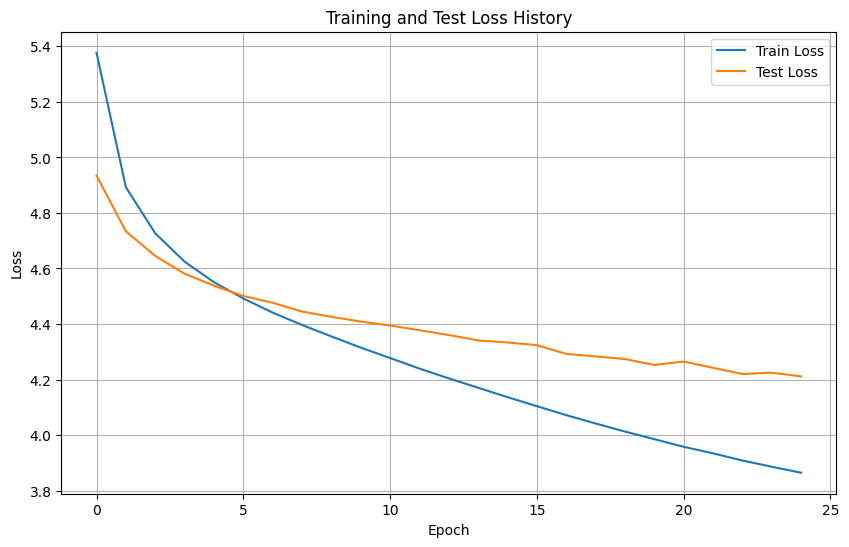

In [25]:
if len(train_loss_history) > 0 and len(val_loss_history) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Test Loss')
    plt.title('Training and Test Loss History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No loss history to plot.")

### Text Generation Function & Examples

In [26]:
def generate_text(
    model,
    prompt,
    seq_len=100,
    max_words=150,
    temperature=1.1,
    top_k=20,
    top_p=1.0 # Added top_p parameter
):
    model.eval()
    generated_words = prompt.lower().split()
    with torch.no_grad():
        for _ in range(max_words):
            # ----------------------------------
            # Encode current text
            # ----------------------------------
            encoded = [
                word2idx.get(word, word2idx["<UNK>"])
                for word in generated_words
            ]

            # Keep only last seq_len tokens
            encoded = encoded[-seq_len:]

            # Left padding if needed
            if len(encoded) < seq_len:
                encoded = (
                    [word2idx["<PAD>"]] * (seq_len - len(encoded))
                    + encoded
                )
            x = torch.tensor(
                encoded,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            # ----------------------------------
            # Model Prediction
            # ----------------------------------
            logits = model(x)

            # Never generate PAD or UNK
            logits[:, word2idx["<PAD>"]] = -float("inf")
            logits[:, word2idx["<UNK>"]] = -float("inf")

            # Temperature Scaling
            logits = logits / temperature

            # Apply top-p (nucleus) sampling if top_p < 1.0
            if top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

                # Remove tokens with cumulative probability above the threshold
                sorted_indices_to_remove = cumulative_probs > top_p
                # Shift the indices to the right to keep at least one token above the threshold
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0 # Ensure the first token is never removed

                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                logits[:, indices_to_remove] = -float("inf")

            # Apply top-k sampling if top_k is specified and top_p was not applied
            # (or top_p was 1.0, effectively not filtering by nucleus)
            elif top_k > 0: # This block is reached if top_p is 1.0 or not provided
                values, _ = torch.topk(logits, top_k)
                min_value = values[:, -1].unsqueeze(1)
                logits = torch.where(logits < min_value, torch.tensor(-float('inf')).to(device), logits)

            # Now, sample from the modified logits (after top-p or top-k or no filtering)
            probs = F.softmax(logits, dim=-1)

            next_token_tensor = torch.multinomial(probs.squeeze(), num_samples=1)
            next_token = next_token_tensor.item()

            next_word = idx2word[next_token]
            generated_words.append(next_word)

    return " ".join(generated_words)


In [35]:
# Test 1:
lyrics_1 = generate_text(
    model=transformer_model,
    prompt="i hate you axel, you're the reason why i'm so fucking pervert like you, now i'm",
    seq_len=50,
    max_words=140,
    temperature=0.8,
    top_k=55,
    top_p=0.75
)

print(lyrics_1)

# Test 2
lyrics_2 = generate_text(
    model=transformer_model,
    prompt="you better stop using your hands on me, i'm victim of physical abuse by my fiance",
    seq_len=20,
    max_words=40,
    temperature=1.3,
    top_k=40,
    top_p=0.97
)

print(lyrics_2)

# Test 3
lyrics_3 = generate_text(
    model=transformer_model,
    prompt="love is whats pay you after being so loyal to her, in return i ditched by",
    seq_len=45,
    max_words=30,
    temperature=2.3,
    top_k=15,
    top_p=0.98
)

print(lyrics_3)

# Test 4: Using top_p sampling
lyrics_4 = generate_text(
    model=transformer_model,
    prompt="i miss",
    seq_len=50,
    max_words=60,
    temperature=0.9,
    top_p=0.95 # Example of top-p usage
)

print(lyrics_4)


i hate you axel, you're the reason why i'm so fucking pervert like you, now i'm coming to give you know when you're my nerves hurt you said you ripped my nerves hurt hurt me lately i ripped out upon my nerves hurt you ripped out to kill the walls of town and ripped out aretha when i was an ambulance and when you know i wants to help me out when you know that you the clock's run away from the reason that you get down like a show 'em on the floor you get the floor that you know what i guess you get it for the streets you that i need to the only get my knees for you do that you're on the show you but you ain't got me the fuck you for me on your brain to the one that you're not to say it i'm the brain how you
you better stop using your hands on me, i'm victim of physical abuse by my fiance you drifting by nature stop hella body pick me knockin' stopping on this hoe bitch stop tryin' get flames down too long night a name on me but you you dropping you see another time time is steady devils 